# Plan d.iii -- Stationarity Testing (Augmented Dickey-Fuller)

Determines the order of integration -- I(0), I(1), or I(2) -- of all six model variables. This
single result decides whether Model A (static OLS) alone is valid, or whether Model B (ARDL
bounds testing) must be estimated as the primary model. This is the most consequential
diagnostic step in the whole pipeline.

See `docs/2_plan/analysis/iii_stationarity_testing.md` for the full spec.

**Input** (`outputs/`):
- `analysis_frame_1990_2024.csv` (from step i)

Six variables are tested: `eri, divp, divm, inflation_rate_pct, exchange_rate, log_fdi`
(`log_fdi`, not raw FDI, per the step i deviation). `shock` is a dummy and is **not** tested for
stationarity.

**Outputs** (`outputs/`):
- `adf_stationarity_results.csv` -- one row per variable x test level (level, 1st diff, and 2nd
  diff only if triggered), with the ADF statistic, p-value, critical values, and the final order
  of integration.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from arch.unitroot import PhillipsPerron
from scipy import stats as scipy_stats
from statsmodels.tsa.stattools import adfuller

ROOT = Path.cwd().resolve().parents[1]
OUTPUT_DIR = ROOT / "outputs"

FRAME_IN = OUTPUT_DIR / "analysis_frame_1990_2024.csv"
ADF_RESULTS_OUT = OUTPUT_DIR / "adf_stationarity_results.csv"

SIGNIFICANCE = 0.05
SPEC_LABEL = {"c": "constant only", "ct": "constant + trend"}


## Step 1 -- Load the analysis frame

In [2]:
frame = pd.read_csv(FRAME_IN)
assert frame.shape[0] == 35, f"expected 35-row analysis frame, got {frame.shape[0]}"

frame = frame.set_index("year")
print(f"frame: {frame.shape}, years {frame.index.min()}-{frame.index.max()}")
frame.head()


frame: (35, 10), years 1990-2024


,eri,divp,divm,divp_source,divm_source,inflation_rate_pct,exchange_rate,fdi_net_inflows_usd,log_fdi,shock
year,,,,,,,,,,
1990,0.3837,0.794432,0.830069,0.7944,0.8506,21.495250,40.06292,4.335512e+07,17.584935,0
1991,0.3678,0.766776,0.811653,0.7668,0.8120,12.185630,41.37150,4.834917e+07,17.693960,0
1992,0.3391,0.723811,0.737246,0.7238,0.7372,11.383440,43.82963,1.226258e+08,18.624648,0
1993,0.5452,0.719521,0.737053,0.7195,0.7371,11.746740,48.32217,1.944791e+08,19.085835,0
1994,0.6214,0.731781,0.729237,0.7318,0.7385,8.448712,49.41514,1.664129e+08,18.929983,0


## Step 2 -- Variables and level-test specification (constant vs. constant + trend)

The ADF specification (constant only vs. constant + trend) is chosen per variable by inspecting
the series plot: a series with a visible trend is tested with a trend term, a series without an
obvious trend is tested with a constant only. Expected defaults (per the plan, informed by step
ii's trend charts): `exchange_rate` and `log_fdi` visibly trend upward over 1990-2024, so they
get a trend term; `eri, divp, divm, inflation_rate_pct` do not, so they get constant-only. The
quick plots below confirm this choice before it is locked in.


In [3]:
VARIABLES = {
    "ERI": "eri",
    "DIVP": "divp",
    "DIVM": "divm",
    "INF": "inflation_rate_pct",
    "EXR": "exchange_rate",
    "log(FDI)": "log_fdi",
}

LEVEL_SPEC = {
    "ERI": "c",
    "DIVP": "c",
    "DIVM": "c",
    "INF": "c",
    "EXR": "ct",
    "log(FDI)": "ct",
}

for label, col in VARIABLES.items():
    print(f"{label:10s} ({col:20s}) -> {SPEC_LABEL[LEVEL_SPEC[label]]}")


ERI        (eri                 ) -> constant only
DIVP       (divp                ) -> constant only
DIVM       (divm                ) -> constant only
INF        (inflation_rate_pct  ) -> constant only
EXR        (exchange_rate       ) -> constant + trend
log(FDI)   (log_fdi             ) -> constant + trend


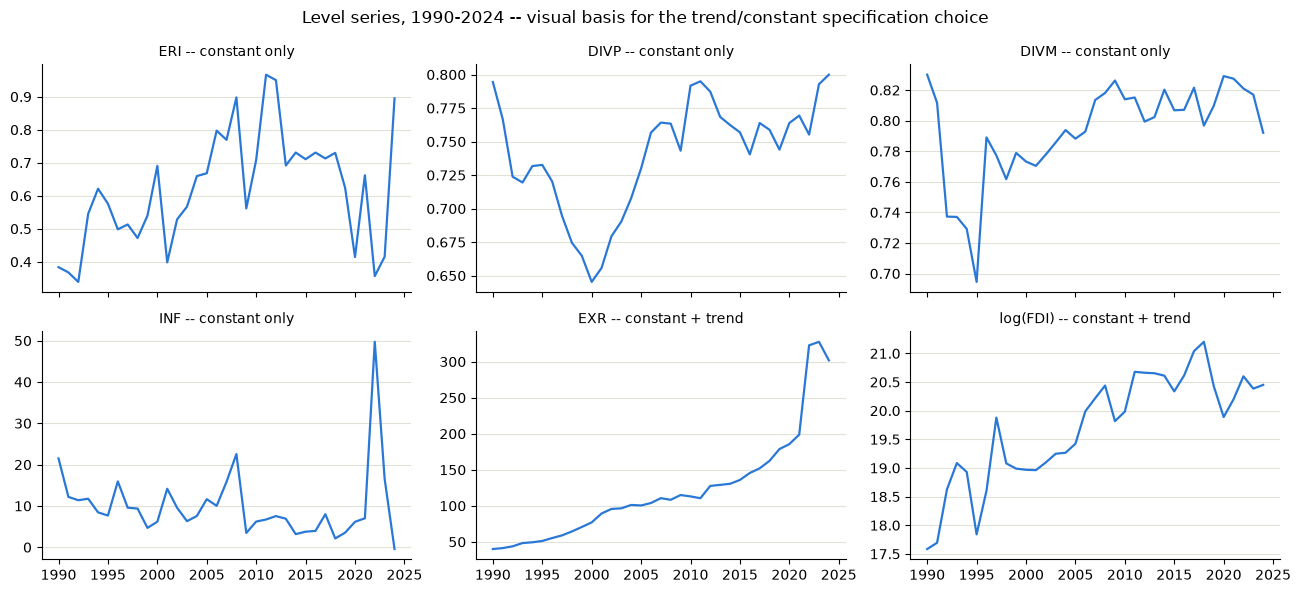

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex=True)
for ax, (label, col) in zip(axes.flat, VARIABLES.items()):
    ax.plot(frame.index, frame[col], lw=1.6, color="#2a78d6")
    ax.set_title(f"{label} -- {SPEC_LABEL[LEVEL_SPEC[label]]}", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e1e0d9", lw=0.8, zorder=-1)
fig.suptitle("Level series, 1990-2024 -- visual basis for the trend/constant specification choice")
fig.tight_layout()
plt.show()


## Step 3 -- ADF test helper

In [5]:
def run_adf(series: pd.Series, regression: str) -> dict:
    """ADF test with AIC-based automatic lag selection (per the plan, given the very short series)."""
    series = series.dropna()
    stat, pvalue, used_lag, nobs, crit_values, _ = adfuller(
        series, regression=regression, autolag="AIC"
    )
    return {
        "test": "ADF (autolag=AIC, uncapped)",
        "specification": SPEC_LABEL[regression],
        "n_obs": nobs,
        "selected_lag": used_lag,
        "stat": stat,
        "p_value": pvalue,
        "crit_1pct": crit_values["1%"],
        "crit_5pct": crit_values["5%"],
        "crit_10pct": crit_values["10%"],
        "stationary_at_5pct": pvalue < SIGNIFICANCE,
    }


## Step 4 -- ADF at level, all six variables

Reject H0 (unit root) at the 5% level -> stationary at level -> I(0). Otherwise, proceed to
first-differencing below.


In [6]:
level_results = []
for label, col in VARIABLES.items():
    res = run_adf(frame[col], regression=LEVEL_SPEC[label])
    res.update({"variable": label, "order_tested": "level"})
    level_results.append(res)

level_df = pd.DataFrame(level_results).set_index("variable")
level_df["conclusion"] = level_df["stationary_at_5pct"].map({True: "stationary", False: "non-stationary"})
level_df[["specification", "selected_lag", "stat", "p_value", "crit_5pct", "conclusion"]]


,specification,selected_lag,stat,p_value,crit_5pct,conclusion
variable,,,,,,
ERI,constant only,0,-3.234477,0.018074,-2.951230,stationary
DIVP,constant only,0,-1.338077,0.611577,-2.951230,non-stationary
DIVM,constant only,0,-2.589069,0.095278,-2.951230,non-stationary
INF,constant only,0,-4.881064,0.000038,-2.951230,stationary
EXR,constant + trend,10,-1.111488,0.927123,-3.612393,non-stationary
log(FDI),constant + trend,2,-1.967689,0.618919,-3.557899,non-stationary


## Step 5 -- ADF on the first difference, for variables that failed the level test

This confirms I(1) and rules out I(2). A first-differenced series should almost never need a
trend term (differencing removes a linear trend), so the default is constant-only -- but this is
checked below (via a simple linear-trend significance test on each differenced series) rather
than assumed, since a residual trend would change the specification.


In [7]:
failed_level = [label for label in VARIABLES if not level_df.loc[label, "stationary_at_5pct"]]
print("Failed the level test (non-stationary at level, proceeding to first differencing):", failed_level)

diff_frame = frame[[VARIABLES[label] for label in failed_level]].diff().dropna()
diff_frame.columns = failed_level
diff_frame.head()


Failed the level test (non-stationary at level, proceeding to first differencing): ['DIVP', 'DIVM', 'EXR', 'log(FDI)']


,DIVP,DIVM,EXR,log(FDI)
year,,,,
1991,-0.027656,-0.018416,1.30858,0.109024
1992,-0.042965,-0.074407,2.45813,0.930689
1993,-0.004290,-0.000193,4.49254,0.461187
1994,0.012260,-0.007816,1.09297,-0.155852
1995,0.000846,-0.034699,1.83645,-1.089199


In [8]:
def has_significant_trend(series: pd.Series, alpha: float = 0.05) -> bool:
    t = np.arange(len(series))
    _, _, _, p_value, _ = scipy_stats.linregress(t, series.values)
    return p_value < alpha

DIFF_SPEC = {}
for label in failed_level:
    trending = has_significant_trend(diff_frame[label])
    DIFF_SPEC[label] = "ct" if trending else "c"
    note = "significant residual trend (p<0.05) -> ct" if trending else "no significant trend -> c (default)"
    print(f"{label:10s} first-differenced trend check: {note}")


DIVP       first-differenced trend check: no significant trend -> c (default)
DIVM       first-differenced trend check: no significant trend -> c (default)
EXR        first-differenced trend check: no significant trend -> c (default)
log(FDI)   first-differenced trend check: no significant trend -> c (default)


In [9]:
diff1_results = []
for label in failed_level:
    res = run_adf(diff_frame[label], regression=DIFF_SPEC[label])
    res.update({"variable": label, "order_tested": "1st difference"})
    diff1_results.append(res)

diff1_df = pd.DataFrame(diff1_results).set_index("variable") if diff1_results else pd.DataFrame()
if not diff1_df.empty:
    diff1_df["conclusion"] = diff1_df["stationary_at_5pct"].map({True: "stationary", False: "non-stationary"})
    display(diff1_df[["specification", "selected_lag", "stat", "p_value", "crit_5pct", "conclusion"]])
else:
    print("No variables required first-differencing -- all six are I(0) at level.")


,specification,selected_lag,stat,p_value,crit_5pct,conclusion
variable,,,,,,
DIVP,constant only,0,-4.626113,1.155867e-04,-2.954127,stationary
DIVM,constant only,0,-6.552404,8.784294e-09,-2.954127,stationary
EXR,constant only,10,0.218031,9.732550e-01,-2.998500,non-stationary
log(FDI),constant only,1,-7.649656,1.803441e-11,-2.957219,stationary


## Step 6 -- ADF on the second difference (I(2) check), only if still non-stationary after 1st diff

If any variable requires a second difference to become stationary, this triggers the
**stop-and-report** branch in step v: ARDL bounds testing is invalid with I(2) regressors.


In [10]:
failed_diff1 = [
    label for label in failed_level
    if label in diff1_df.index and not diff1_df.loc[label, "stationary_at_5pct"]
]
print("Still non-stationary after first differencing (I(2) candidates):", failed_diff1)

diff2_results = []
if failed_diff1:
    diff2_frame = diff_frame[failed_diff1].diff().dropna()
    for label in failed_diff1:
        res = run_adf(diff2_frame[label], regression="c")
        res.update({"variable": label, "order_tested": "2nd difference"})
        diff2_results.append(res)
    diff2_df = pd.DataFrame(diff2_results).set_index("variable")
    diff2_df["conclusion"] = diff2_df["stationary_at_5pct"].map({True: "stationary", False: "non-stationary"})
    display(diff2_df[["specification", "selected_lag", "stat", "p_value", "crit_5pct", "conclusion"]])
else:
    diff2_df = pd.DataFrame()
    print("No second-difference test needed -- no variable remained non-stationary after first differencing.")


Still non-stationary after first differencing (I(2) candidates): ['EXR']


,specification,selected_lag,stat,p_value,crit_5pct,conclusion
variable,,,,,,
EXR,constant only,9,0.68599,0.989554,-2.9985,non-stationary


## Step 7 -- Order-of-integration classification and results table

In [11]:
def classify_order(label: str) -> str:
    if level_df.loc[label, "stationary_at_5pct"]:
        return "I(0)"
    if label in failed_diff1:
        return "I(2)"
    return "I(1)"

# Provisional -- the mechanical outcome of the literal Step 4-6 procedure (uncapped autolag="AIC").
# Any I(2) result here is provisional pending the robustness check in Step 8b, not final.
order_of_integration = {label: classify_order(label) for label in VARIABLES}
pd.Series(order_of_integration, name="order_of_integration").rename_axis("variable")


variable
ERI         I(0)
DIVP        I(1)
DIVM        I(1)
INF         I(0)
EXR         I(2)
log(FDI)    I(1)
Name: order_of_integration, dtype: str

## Step 8 -- I(2) stop-and-flag check (literal-spec procedure)

Flags any I(2) result from the mechanical Step 4-6 procedure before proceeding. Per the plan,
an I(2) finding here is not resolved silently -- it is investigated below (Step 8b) rather than
either accepted at face value or discarded.


In [12]:
i2_vars = [label for label, order in order_of_integration.items() if order == "I(2)"]
if i2_vars:
    print("Provisional I(2) result(s) under the literal autolag='AIC' spec:", i2_vars)
    print("Investigating with a lag-selection-robust cross-check before treating this as final.")
else:
    print("No I(2) results among the six variables under the literal spec.")


Provisional I(2) result(s) under the literal autolag='AIC' spec: ['EXR']
Investigating with a lag-selection-robust cross-check before treating this as final.


## Step 8b -- Robustness check for any provisional-I(2) variable

The uncapped autolag="AIC" ADF selected a lag of 9-10 for EXR (see Step 4-6 above) out of only
~24-34 usable observations -- a large share of an already tiny sample spent on lag terms, and a
known failure mode of automatic lag selection on very short series: it can produce a "never
stationary at any differencing order" result regardless of the series' true order of
integration. Two cross-checks that are less sensitive to that specific failure mode:

1. **Capped-lag ADF, `maxlag=4`, selected via AIC and via BIC separately.** Annual macro series
   rarely need lags beyond 2-4; both criteria are reported since they can disagree.
2. **Phillips-Perron.** Corrects for serial correlation via a nonparametric (Newey-West-type)
   adjustment to the test statistic itself rather than by adding lagged-difference regressors, so
   it does not sacrifice sample size to lag terms the way ADF does -- a useful tiebreaker here.


In [13]:
def run_adf_capped(series: pd.Series, regression: str, maxlag: int, variable: str, order_tested: str) -> list[dict]:
    rows = []
    for method in ("aic", "bic"):
        stat, pvalue, used_lag, nobs, crit_values, _ = adfuller(
            series.dropna(), regression=regression, autolag=method, maxlag=maxlag
        )
        rows.append({
            "variable": variable,
            "order_tested": order_tested,
            "test": f"ADF (autolag={method.upper()}, maxlag={maxlag})",
            "specification": SPEC_LABEL[regression],
            "n_obs": nobs,
            "selected_lag": used_lag,
            "stat": stat,
            "p_value": pvalue,
            "crit_1pct": crit_values["1%"],
            "crit_5pct": crit_values["5%"],
            "crit_10pct": crit_values["10%"],
            "stationary_at_5pct": pvalue < SIGNIFICANCE,
        })
    return rows


def run_pp(series: pd.Series, trend: str, variable: str, order_tested: str) -> dict:
    pp = PhillipsPerron(series.dropna().values, trend=trend)
    return {
        "variable": variable,
        "order_tested": order_tested,
        "test": "Phillips-Perron",
        "specification": SPEC_LABEL[trend],
        "n_obs": len(series.dropna()) - 1,
        "selected_lag": pp.lags,
        "stat": pp.stat,
        "p_value": pp.pvalue,
        "crit_1pct": pp.critical_values["1%"],
        "crit_5pct": pp.critical_values["5%"],
        "crit_10pct": pp.critical_values["10%"],
        "stationary_at_5pct": pp.pvalue < SIGNIFICANCE,
    }


exr_robustness_rows = []
if "EXR" in i2_vars:
    exr_col = VARIABLES["EXR"]
    exr_level = frame[exr_col]
    exr_diff1 = exr_level.diff().dropna()

    exr_robustness_rows += run_adf_capped(exr_level, "ct", 4, "EXR", "level")
    exr_robustness_rows += run_adf_capped(exr_diff1, "c", 4, "EXR", "1st difference")
    exr_robustness_rows.append(run_pp(exr_level, "ct", "EXR", "level"))
    exr_robustness_rows.append(run_pp(exr_diff1, "c", "EXR", "1st difference"))

    robustness_df = pd.DataFrame(exr_robustness_rows)
    robustness_df["conclusion"] = robustness_df["stationary_at_5pct"].map({True: "stationary", False: "non-stationary"})
    display(robustness_df[["order_tested", "test", "selected_lag", "n_obs", "stat", "p_value", "crit_5pct", "conclusion"]])
else:
    print("Skipped -- no provisional I(2) variable to cross-check.")


,order_tested,test,selected_lag,n_obs,stat,p_value,crit_5pct,conclusion
0,level,"ADF (autolag=AIC, maxlag=4)",2,32,2.865994,1.000000,-3.557899,non-stationary
1,level,"ADF (autolag=BIC, maxlag=4)",2,32,2.865994,1.000000,-3.557899,non-stationary
2,1st difference,"ADF (autolag=AIC, maxlag=4)",2,31,1.294358,0.996577,-2.960525,non-stationary
3,1st difference,"ADF (autolag=BIC, maxlag=4)",2,31,1.294358,0.996577,-2.960525,non-stationary
4,level,Phillips-Perron,10,34,-1.064488,0.934787,-3.548590,non-stationary
5,1st difference,Phillips-Perron,10,33,-5.053762,0.000017,-2.954127,stationary


## Step 8c -- Apply the decision rule

**Decision rule:** if either the capped-lag ADF (AIC or BIC) or Phillips-Perron now shows the
first-differenced series as stationary at 5%, treat the variable as I(1) and proceed. Otherwise,
it remains I(2) and is not forced into ARDL.


In [14]:
if "EXR" in i2_vars:
    diff1_evidence = [
        row for row in exr_robustness_rows
        if row["order_tested"] == "1st difference" and row["stationary_at_5pct"]
    ]
    if diff1_evidence:
        order_of_integration["EXR"] = "I(1)"
        tests_that_reject = ", ".join(row["test"] for row in diff1_evidence)
        print(f"Decision: EXR resolved to I(1) -- {tests_that_reject} reject the unit-root null")
        print("on the first-differenced series at 5%, overriding the provisional I(2) call.")
    else:
        print("Decision: EXR remains I(2) -- no robustness check rejected the unit-root null")
        print("on the first-differenced series. Proceeding to the depreciation-rate fallback.")
    print("EXR order of integration (resolved):", order_of_integration["EXR"])
else:
    print("Not applicable -- no provisional I(2) variable.")


Decision: EXR resolved to I(1) -- Phillips-Perron reject the unit-root null
on the first-differenced series at 5%, overriding the provisional I(2) call.
EXR order of integration (resolved): I(1)


## Step 8d -- Depreciation-rate fallback (only runs if EXR is still I(2) after Step 8c)

Standard fix for a trending nominal exchange rate that resists differencing: switch from the
level to its year-on-year percentage change (the depreciation rate) and re-test. Only executes
if the robustness check above did not resolve EXR to I(1); documented here as a deviation from
the literal thesis spec, with the ADF evidence behind it, if it triggers.


In [15]:
exr_fallback_rows = []
if order_of_integration.get("EXR") == "I(2)":
    depreciation_rate = frame[VARIABLES["EXR"]].pct_change().dropna() * 100
    dep_res = run_adf(depreciation_rate, regression="c")
    dep_res.update({"variable": "EXR_yoy_pct", "order_tested": "level"})
    exr_fallback_rows.append(dep_res)

    print(f"Depreciation rate (YoY %% change) ADF: lag={dep_res['selected_lag']}, "
          f"stat={dep_res['stat']:.4f}, p={dep_res['p_value']:.4f}")
    if dep_res["stationary_at_5pct"]:
        order_of_integration["EXR_yoy_pct"] = "I(0)"
        print(
            "Depreciation rate is stationary at level -- substitute EXR (level) with the "
            "depreciation rate as the exchange-rate regressor in steps iv/vi. Documented "
            "deviation: EXR enters the model as year-on-year %% change, not the level, because "
            "the level is I(2) and the depreciation rate is I(0)."
        )
    else:
        print(
            "Depreciation rate is still non-stationary -- escalate to the user before proceeding; "
            "no further automatic fallback is applied here."
        )
else:
    print("Not needed -- EXR resolved to I(1) (or I(0)) in Step 8c.")


Not needed -- EXR resolved to I(1) (or I(0)) in Step 8c.


## Step 9 -- Final results table (all tests) and I(2) stop-and-flag re-check

In [16]:
all_rows = level_results + diff1_results + diff2_results + exr_robustness_rows + exr_fallback_rows
results_table = pd.DataFrame(all_rows)
results_table["conclusion"] = results_table["stationary_at_5pct"].map({True: "stationary", False: "non-stationary"})
results_table["order_of_integration"] = results_table["variable"].map(order_of_integration)

column_order = [
    "variable", "order_tested", "test", "specification", "selected_lag", "n_obs",
    "stat", "p_value", "crit_1pct", "crit_5pct", "crit_10pct",
    "conclusion", "order_of_integration",
]
order_rank = {"level": 0, "1st difference": 1, "2nd difference": 2}
results_table = results_table[column_order].sort_values(
    by=["variable", "order_tested"],
    key=lambda s: s.map(order_rank) if s.name == "order_tested" else s,
)

results_table.to_csv(ADF_RESULTS_OUT, index=False)
print(f"Written -> {ADF_RESULTS_OUT}")
results_table


Written -> /Users/mohamedinas/Desktop/SE_projects/11_fathima_research/1_eda_and_modeling/8_interview_prep/outputs/adf_stationarity_results.csv


,variable,order_tested,test,specification,selected_lag,n_obs,stat,p_value,crit_1pct,crit_5pct,crit_10pct,conclusion,order_of_integration
2,DIVM,level,"ADF (autolag=AIC, uncapped)",constant only,0,34,-2.589069,9.527758e-02,-3.639224,-2.951230,-2.614447,non-stationary,I(1)
7,DIVM,1st difference,"ADF (autolag=AIC, uncapped)",constant only,0,33,-6.552404,8.784294e-09,-3.646135,-2.954127,-2.615968,stationary,I(1)
1,DIVP,level,"ADF (autolag=AIC, uncapped)",constant only,0,34,-1.338077,6.115770e-01,-3.639224,-2.951230,-2.614447,non-stationary,I(1)
6,DIVP,1st difference,"ADF (autolag=AIC, uncapped)",constant only,0,33,-4.626113,1.155867e-04,-3.646135,-2.954127,-2.615968,stationary,I(1)
0,ERI,level,"ADF (autolag=AIC, uncapped)",constant only,0,34,-3.234477,1.807376e-02,-3.639224,-2.951230,-2.614447,stationary,I(0)
4,EXR,level,"ADF (autolag=AIC, uncapped)",constant + trend,10,24,-1.111488,9.271227e-01,-4.395041,-3.612393,-3.243216,non-stationary,I(1)
11,EXR,level,"ADF (autolag=AIC, maxlag=4)",constant + trend,2,32,2.865994,1.000000e+00,-4.273535,-3.557899,-3.212366,non-stationary,I(1)
12,EXR,level,"ADF (autolag=BIC, maxlag=4)",constant + trend,2,32,2.865994,1.000000e+00,-4.273535,-3.557899,-3.212366,non-stationary,I(1)
15,EXR,level,Phillips-Perron,constant + trend,10,34,-1.064488,9.347870e-01,-4.253043,-3.548590,-3.207062,non-stationary,I(1)
8,EXR,1st difference,"ADF (autolag=AIC, uncapped)",constant only,10,23,0.218031,9.732550e-01,-3.752928,-2.998500,-2.638967,non-stationary,I(1)


In [17]:
i2_vars_final = [label for label, order in order_of_integration.items() if order == "I(2)"]
if i2_vars_final:
    print("STOP -- I(2) result(s) remain after the robustness check:", i2_vars_final)
    print(
        "Per the plan, this must be flagged back to the user immediately before proceeding to "
        "step iv/v -- ARDL bounds testing (Model B) is invalid with I(2) regressors."
    )
else:
    print("No I(2) results remain among the tested variables.")
    print("Safe to proceed to step iv (multicollinearity check) and step v (decision branch).")


No I(2) results remain among the tested variables.
Safe to proceed to step iv (multicollinearity check) and step v (decision branch).


## Caveat -- low power with n = 35 (or 34 after differencing)

With only 35 observations at level (34 at first difference, 33 at second), the ADF test has low
power to reject a false unit-root null. This does not change the mechanical conclusions above,
but it means I(0) vs. I(1) calls near the 5% boundary should be stated with appropriate caution
rather than treated as definitive, and is worth restating alongside any borderline p-value in the
write-up. It is also the reason EXR's level test needed the Step 8b/8c cross-check in the first
place: the same short-sample fragility that weakens ADF's power shows up even more acutely once
automatic lag selection is added on top of it.


## Conclusion -- order of integration per variable (feeds into step v)

**ERI -- I(0).** Stationary at level (constant only, lag 0): ADF stat -3.234, p = 0.018,
rejects the unit-root null at 5%.

**INF (inflation_rate_pct) -- I(0).** Stationary at level (constant only, lag 0): ADF stat
-4.881, p = 3.8e-05. Rejects the unit-root null decisively.

**DIVP -- I(1).** Non-stationary at level (constant only, lag 0): ADF stat -1.338, p = 0.612.
Stationary after first differencing (constant only, lag 0): ADF stat -4.626, p = 0.0001.

**DIVM -- I(1).** Non-stationary at level (constant only, lag 0): ADF stat -2.589, p = 0.095 --
closer to the 5% boundary than the other non-stationary series, so its non-stationarity call at
level is the least confident of the six (see the low-power caveat below). Stationary after first
differencing (constant only, lag 0): ADF stat -6.552, p = 8.8e-09.

**log(FDI) -- I(1).** Non-stationary at level (constant + trend, lag 2): ADF stat -1.968,
p = 0.619. Stationary after first differencing (constant only, lag 1): ADF stat -7.650,
p = 1.8e-11.

**EXR (exchange_rate) -- I(1), resolved after a robustness check.** The literal
autolag="AIC" procedure (Step 4-6) never rejected the unit-root null at any differencing order:
level (constant+trend, lag 10, p = 0.927), 1st difference (constant only, lag 10, p = 0.973),
2nd difference (constant only, lag 9, p = 0.990) -- a provisional I(2) call. But the AIC-selected
lag was 9-10 at every stage, consuming 9-10 of the already-small 34/33/32 usable observations --
a large share of the sample spent on lag terms, and a known way for automatic lag selection to
manufacture exactly this "never stationary" pattern regardless of the series' true order of
integration.

The Step 8b/8c robustness check resolved this. Capping the ADF at `maxlag=4` (both AIC- and
BIC-selected, lag 2 in both cases) still failed to reject on the first difference (p = 0.997),
so the capped-lag ADF alone did not settle it either. **Phillips-Perron was the tiebreaker**: it
does not spend sample size on lagged-difference regressors, and on EXR's first difference it
rejects the unit-root null decisively (stat -5.054, p = 1.7e-05), while still failing to reject
at level (stat -1.064, p = 0.935, consistent with all the other tests). Per the decision rule
(treat as I(1) if either the capped-lag ADF or PP shows the first difference as stationary), EXR
is classified **I(1)**, and the depreciation-rate fallback (Step 8d) was not needed.

**Net classification -- all six variables, no I(2):** ERI and INF are I(0); DIVP, DIVM,
log(FDI), and EXR are I(1). This is a clean **mixed I(0)/I(1) case with no I(2) regressor**,
which is Branch B in step v's decision rule (ARDL bounds testing as the primary model, with
static OLS on levels and OLS on first differences reported alongside for comparison).

**Low-power caveat:** with only 35 (34, 33, ...) observations, every ADF test above has limited
power to reject a false unit-root null. This qualifies confidence in all six order-of-integration
calls -- e.g. DIVM's level p-value (0.095) is the closest to the 5% boundary of the
non-stationary-at-level results -- and it is also the underlying reason EXR needed the extra
robustness check: the same short-sample fragility that weakens ADF's power is compounded when
automatic lag selection is layered on top of it.
